**Cardiovascular Disease Prediction Using Machine Learning**

Name: Vidya M.V  
Dataset: Cardio Vascular Disease Detection (Kaggle)  
Target: cardio (0 = No CVD, 1 = CVD present)  

**Step 1: Import Required Libraries**

Import libraries for:
- Data handling: pandas, numpy
- Visualization: matplotlib, seaborn
- ML models and evaluation: scikit-learn
- Model saving: joblib

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and feature selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Save / load model
import joblib
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


**Step 2: Data Collection - Load the Dataset**

In [2]:
# Load dataset

df = pd.read_csv('cardio_train.csv', sep=';')

print('Dataset shape (rows, columns):', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape (rows, columns): (69301, 13)

First 5 rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,988,22469,1,155,69.0,130,80,2,2,0,0,1,0
1,989,14648,1,163,71.0,110,70,1,1,0,0,1,1
2,990,21901,1,165,70.0,120,80,1,1,0,0,1,0
3,991,14549,2,165,85.0,120,80,1,1,1,1,1,0
4,992,23393,1,155,62.0,120,80,1,1,0,0,1,0


**Step 3: Understand the Dataset (Initial Exploration)**

- Column names and data types
- Missing values
- Basic statistics
- Target class distribution

In [3]:
# Basic info
print('Column names:\n', df.columns.tolist())
print('\n--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())
print('\n--- Duplicate Rows ---')
print(df.duplicated().sum())

Column names:
 ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

--- Data Types ---
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

--- Missing Values ---
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

--- Duplicate Rows ---
0


In [4]:
# Statistical summary of numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,69301.0,50471.480397,28563.100347,988.0,25745.0,50494.0,75150.0,99999.0
age,69301.0,19468.786280,2467.261818,10798.0,17664.0,19704.0,21326.0,23713.0
gender,69301.0,1.349519,0.476821,1.0,1.0,1.0,2.0,2.0
height,69301.0,164.362217,8.205337,55.0,159.0,165.0,170.0,250.0
weight,69301.0,74.203027,14.383469,10.0,65.0,72.0,82.0,200.0
ap_hi,69301.0,128.829584,154.775805,-150.0,120.0,120.0,140.0,16020.0
ap_lo,69301.0,96.650092,189.096240,-70.0,80.0,80.0,90.0,11000.0
cholesterol,69301.0,1.366806,0.680270,1.0,1.0,1.0,2.0,3.0
gluc,69301.0,1.226447,0.572246,1.0,1.0,1.0,1.0,3.0
smoke,69301.0,0.088051,0.283371,0.0,0.0,0.0,0.0,1.0


Target class counts:
cardio
0    34679
1    34622
Name: count, dtype: int64

Target class percentages:
cardio
0    50.041125
1    49.958875
Name: proportion, dtype: float64


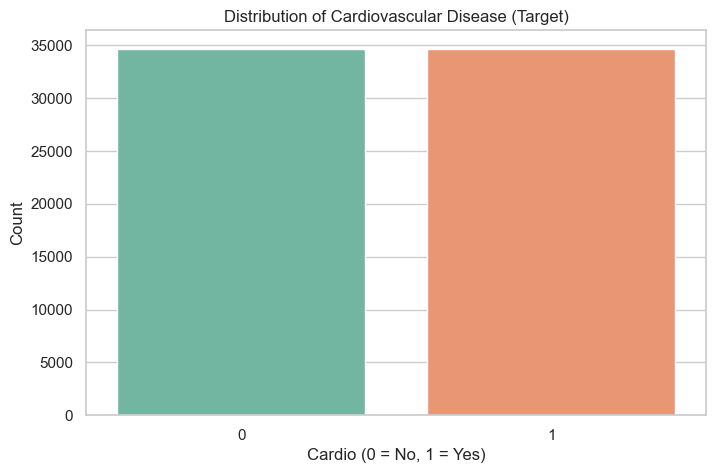

In [5]:
# Target distribution
print('Target class counts:')
print(df['cardio'].value_counts())
print('\nTarget class percentages:')
print(df['cardio'].value_counts(normalize=True) * 100)

sns.countplot(x='cardio', data=df, palette='Set2')
plt.title('Distribution of Cardiovascular Disease (Target)')
plt.xlabel('Cardio (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

**Step 4: Data Preprocessing - Data Cleaning**

- Drop non-predictive column (id)
- Convert age from days to years
- Remove invalid / outlier records (unrealistic BP, height, weight)
- Confirm no missing values remain

In [6]:
# Working copy so original df remains unchanged
data = df.copy()

# Drop ID column (not useful for prediction)
if 'id' in data.columns:
    data = data.drop(columns=['id'])

# Convert age from days to years
data['age'] = (data['age'] / 365).round().astype(int)

print('Age converted to years. Sample ages:', data['age'].head().tolist())
print('Age range:', data['age'].min(), 'to', data['age'].max())

Age converted to years. Sample ages: [62, 40, 60, 40, 64]
Age range: 30 to 65


In [7]:
# Remove invalid measurements
rows_before = len(data)
print('Rows before cleaning:', rows_before)

data = data[
    (data['ap_hi'] > 80) & (data['ap_hi'] < 250) &      # systolic BP
    (data['ap_lo'] > 40) & (data['ap_lo'] < 180) &      # diastolic BP
    (data['ap_hi'] > data['ap_lo']) &                   # systolic must be higher
    (data['height'] > 120) & (data['height'] < 220) &
    (data['weight'] > 30) & (data['weight'] < 200)
].copy()

print('Rows after cleaning:', len(data))
print('Rows removed:', rows_before - len(data))

Rows before cleaning: 69301
Rows after cleaning: 67819
Rows removed: 1482


In [8]:
# Missing-value and duplicate check after cleaning
print('Missing values after cleaning:')
print(data.isnull().sum())

# Recheck duplicates AFTER dropping id
dup_count = data.duplicated().sum()
print('\nDuplicate rows after dropping id:', dup_count)
if dup_count > 0:
    data = data.drop_duplicates().copy()
    print('Duplicates removed. New shape:', data.shape)

print('\nCleaned dataset shape:', data.shape)
data.head()


Missing values after cleaning:
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Duplicate rows after dropping id: 3762
Duplicates removed. New shape: (64057, 12)

Cleaned dataset shape: (64057, 12)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,62,1,155,69.0,130,80,2,2,0,0,1,0
1,40,1,163,71.0,110,70,1,1,0,0,1,1
2,60,1,165,70.0,120,80,1,1,0,0,1,0
3,40,2,165,85.0,120,80,1,1,1,1,1,0
4,64,1,155,62.0,120,80,1,1,0,0,1,0


**Step 5: Exploratory Data Analysis (EDA)**
-  visualizations to understand distributions and relationships with CVD
                                    

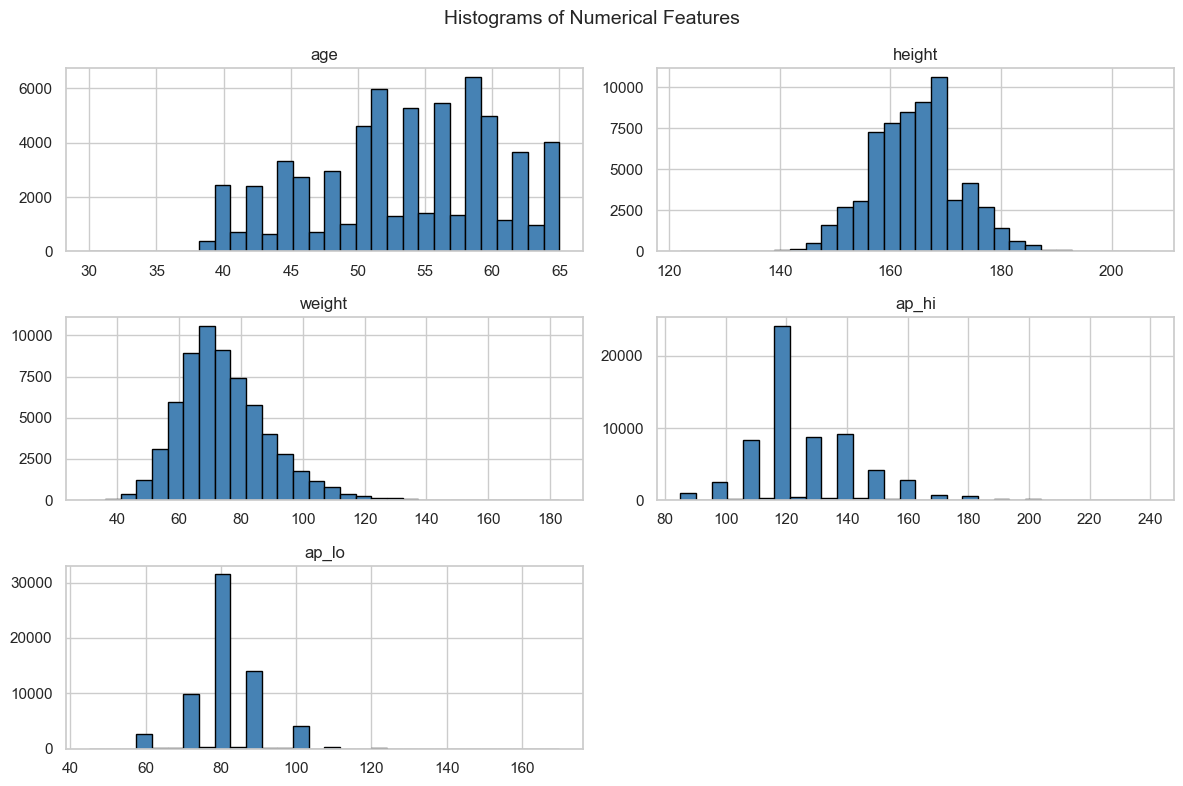

In [9]:
# Histograms for key numerical features
num_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
data[num_cols].hist(bins=30, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

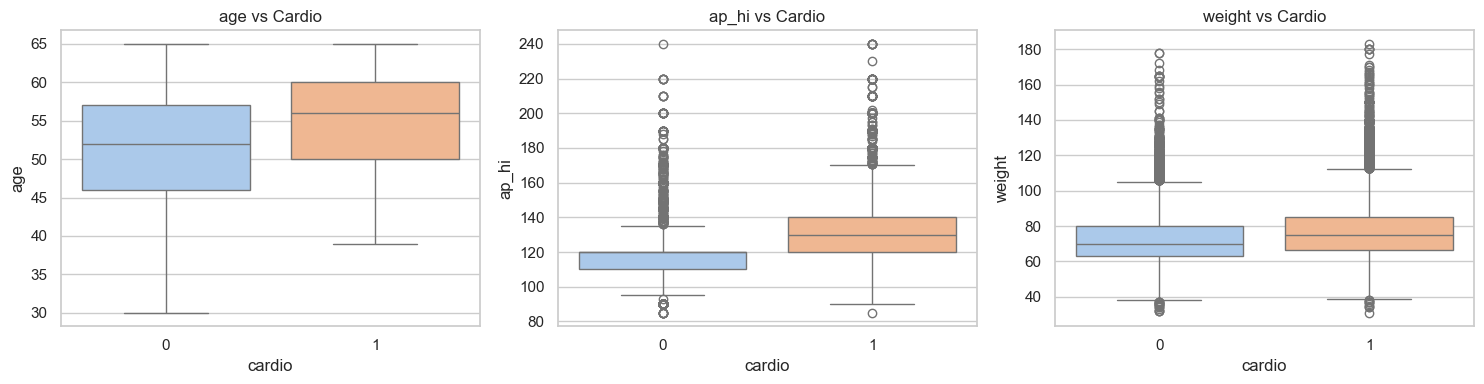

In [10]:
# Boxplots: compare feature distributions by CVD status
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['age', 'ap_hi', 'weight']):
    sns.boxplot(x='cardio', y=col, data=data, ax=ax, palette='pastel')
    ax.set_title(f'{col} vs Cardio')
plt.tight_layout()
plt.show()

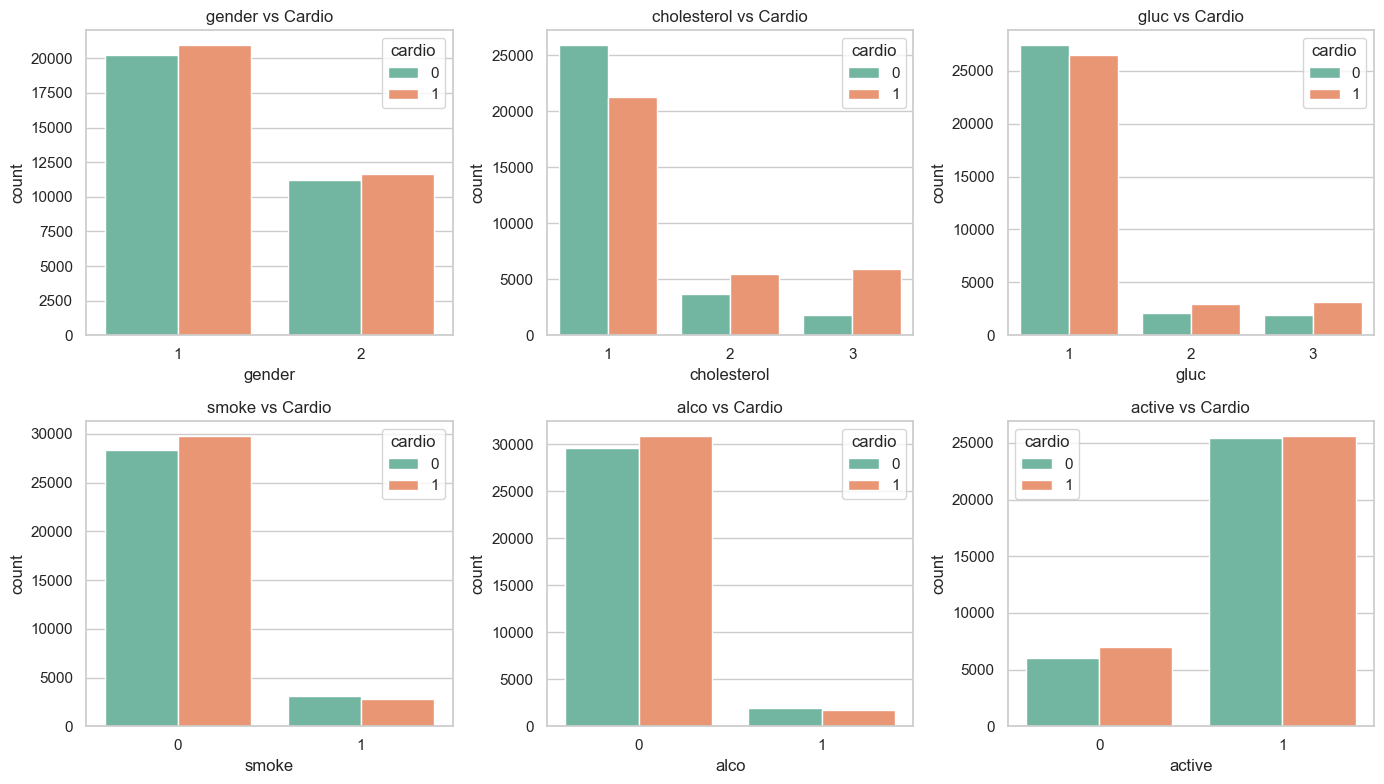

In [11]:
# Count plots for categorical / binary features
cat_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue='cardio', data=data, ax=ax, palette='Set2')
    ax.set_title(f'{col} vs Cardio')
plt.tight_layout()
plt.show()


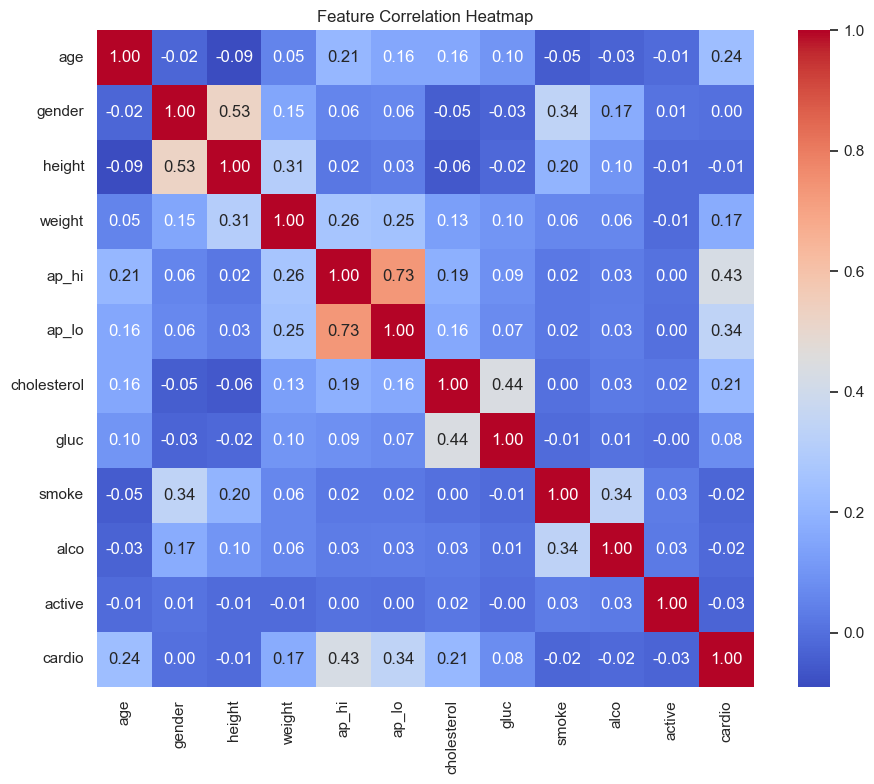

Correlation with cardio (sorted):
cardio         1.000000
ap_hi          0.425740
ap_lo          0.341157
age            0.235280
cholesterol    0.212917
weight         0.173078
gluc           0.080374
gender         0.000604
height        -0.011482
alco          -0.015293
smoke         -0.023922
active        -0.029307
Name: cardio, dtype: float64


In [12]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print('Correlation with cardio (sorted):')
print(corr['cardio'].sort_values(ascending=False))

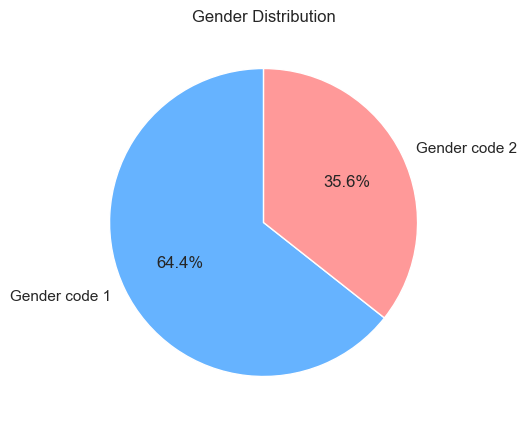

In [13]:
# Pie chart - gender distribution
gender_counts = data['gender'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(
    gender_counts,
    labels=['Gender code ' + str(i) for i in gender_counts.index],
    autopct='%1.1f%%',
    colors=['#66b3ff', '#ff9999'],
    startangle=90
)
plt.title('Gender Distribution')
plt.show()

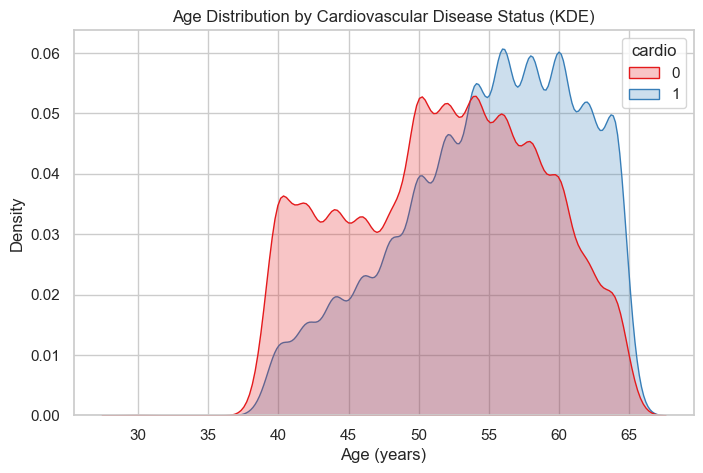

In [14]:
# KDE: Age distribution by CVD status
plt.figure(figsize=(8, 5))
sns.kdeplot(data=data, x='age', hue='cardio', fill=True, common_norm=False, palette='Set1')
plt.title('Age Distribution by Cardiovascular Disease Status (KDE)')
plt.xlabel('Age (years)')
plt.show()

**Step 6: Feature Engineering**

Create useful derived features:
- BMI = weight (kg) / [height (m)] squared
- pulse_pressure = systolic BP - diastolic BP

In [15]:
# Body Mass Index (combines height + weight into one clinical feature)
data['bmi'] = data['weight'] / ((data['height'] / 100) ** 2)

# Pulse pressure is a LINEAR combination of ap_hi and ap_lo (ap_hi - ap_lo).
# Keep it only for a quick look, then drop it before modeling to avoid multicollinearity.
data['pulse_pressure'] = data['ap_hi'] - data['ap_lo']

print('New features added: bmi, pulse_pressure')
print(data[['height', 'weight', 'bmi', 'ap_hi', 'ap_lo', 'pulse_pressure']].head())

New features added: bmi, pulse_pressure
   height  weight        bmi  ap_hi  ap_lo  pulse_pressure
0     155    69.0  28.720083    130     80              50
1     163    71.0  26.722873    110     70              40
2     165    70.0  25.711662    120     80              40
3     165    85.0  31.221304    120     80              40
4     155    62.0  25.806452    120     80              40


In [16]:
# Remove extreme BMI values if present
print('BMI range before filter:', round(data['bmi'].min(), 2), '-', round(data['bmi'].max(), 2))
data = data[(data['bmi'] >= 10) & (data['bmi'] <= 60)].copy()
print('Rows after BMI filter:', len(data))

# Drop redundant columns:
# - height & weight are already captured by BMI
# - pulse_pressure is exactly ap_hi - ap_lo (perfect multicollinearity)
data = data.drop(columns=['height', 'weight', 'pulse_pressure'])
print('Columns after dropping redundant features:', data.columns.tolist())
print('Final modeling shape:', data.shape)

BMI range before filter: 10.73 - 108.17
Rows after BMI filter: 64038
Columns after dropping redundant features: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'bmi']
Final modeling shape: (64038, 11)


**Step7: Define Features (X) and Target (y)**

In [17]:
# Separate features and target
X = data.drop(columns=['cardio'])
y = data['cardio']

print('Feature columns:', X.columns.tolist())
print('X shape:', X.shape)
print('y shape:', y.shape)
print('\nClass balance:')
print(y.value_counts(normalize=True))

Feature columns: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
X shape: (64038, 10)
y shape: (64038,)

Class balance:
cardio
1    0.508839
0    0.491161
Name: proportion, dtype: float64


**Step 8: Feature Selection**

Use SelectKBest (ANOVA F-test) and Random Forest importance to identify relevant features.

SelectKBest Feature Scores (exploratory, full data):
       Feature         Score
2        ap_hi  14175.618075
3        ap_lo   8428.932573
0          age   3754.916368
4  cholesterol   3041.822951
9          bmi   2257.451530
5         gluc    415.442989
8       active     55.158025
6        smoke     36.473727
7         alco     14.833673
1       gender      0.034597


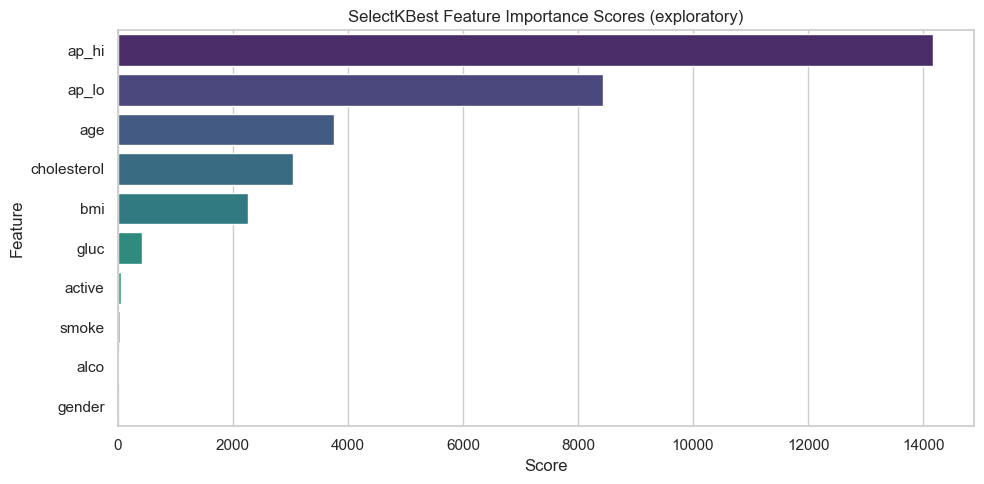

In [18]:
# SelectKBest — EXPLORATORY ranking on all rows (we don't drop features from this cell).
# Final ranking is repeated on TRAIN only after the split, to avoid test leakage.
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print('SelectKBest Feature Scores (exploratory, full data):')
print(feature_scores)

plt.figure(figsize=(10, 5))
sns.barplot(x='Score', y='Feature', data=feature_scores, palette='viridis')
plt.title('SelectKBest Feature Importance Scores (exploratory)')
plt.tight_layout()
plt.show()

Random Forest Feature Importance (exploratory, full data):
       Feature  Importance
9          bmi    0.479417
2        ap_hi    0.182929
0          age    0.142846
3        ap_lo    0.086921
4  cholesterol    0.039095
5         gluc    0.019413
1       gender    0.017544
8       active    0.014053
6        smoke    0.009379
7         alco    0.008403


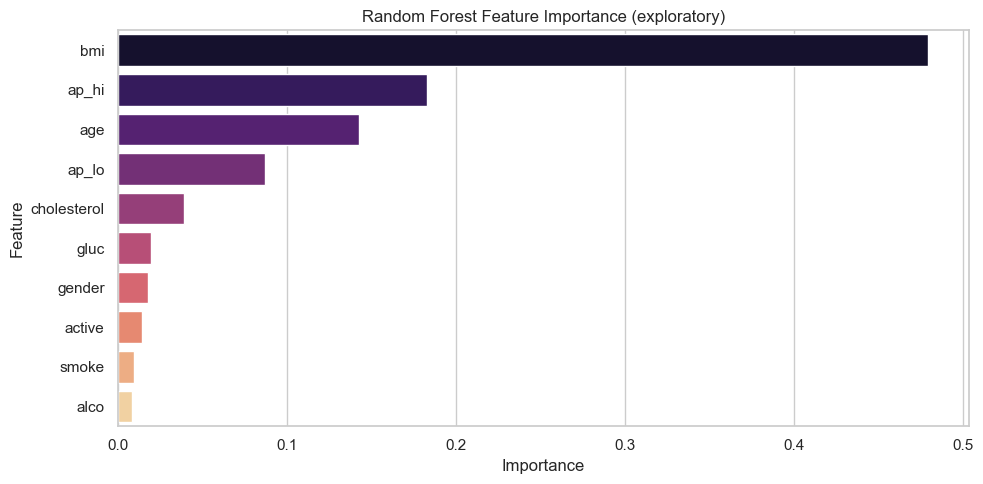

In [19]:
# Random Forest feature importance — exploratory only (uses all rows).
# we don't drop columns from this ranking before the train/test split.
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X, y)

rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('Random Forest Feature Importance (exploratory, full data):')
print(rf_importance)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=rf_importance, palette='magma')
plt.title('Random Forest Feature Importance (exploratory)')
plt.tight_layout()
plt.show()

In [20]:
# We don't drop features using scores computed on the FULL dataset.
# That leaks test-set information. Final keep/drop is decided after the split.
print('Candidate features before split:', X.columns.tolist())

Candidate features before split: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']


**Step 9: Split Data into Training and Testing Sets**


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)
print('\nTrain class ratio:')
print(y_train.value_counts(normalize=True))
print('\nTest class ratio:')
print(y_test.value_counts(normalize=True))

# Feature ranking on TRAIN only (no test leakage)
selector_train = SelectKBest(score_func=f_classif, k='all')
selector_train.fit(X_train, y_train)
train_scores = pd.DataFrame({
    'Feature': X_train.columns,
    'Train_F_Score': selector_train.scores_
}).sort_values(by='Train_F_Score', ascending=False)
print('\nSelectKBest scores on TRAINING data only:')
print(train_scores)

Training set: (51230, 10)
Testing set : (12808, 10)

Train class ratio:
cardio
1    0.508842
0    0.491158
Name: proportion, dtype: float64

Test class ratio:
cardio
1    0.508823
0    0.491177
Name: proportion, dtype: float64

SelectKBest scores on TRAINING data only:
       Feature  Train_F_Score
2        ap_hi   11515.061318
3        ap_lo    6806.518383
0          age    3108.894141
4  cholesterol    2477.796158
9          bmi    1758.775685
5         gluc     350.732036
8       active      40.256978
6        smoke      25.256214
7         alco       9.510719
1       gender       0.021735


**Step 10: Feature Scaling**

- Apply StandardScaler (mean = 0, std = 1).
- Important for Logistic Regression, SVM, KNN, etc. Tree models are less sensitive to scale.

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Optional: keep column names for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print('Scaling complete.')
print('Train mean (approx 0):')
print(X_train_scaled.mean().round(4).head())
print('\nTrain std (approx 1):')
print(X_train_scaled.std().round(4).head())

Scaling complete.
Train mean (approx 0):
age            0.0
gender        -0.0
ap_hi         -0.0
ap_lo          0.0
cholesterol    0.0
dtype: float64

Train std (approx 1):
age            1.0
gender         1.0
ap_hi          1.0
ap_lo          1.0
cholesterol    1.0
dtype: float64


**Step 11: Build Machine Learning Models**

- Train multiple classifiers on the same split and compare Accuracy, Precision, Recall, F1, and ROC-AUC.

In [23]:
# Dictionary of models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = np.nan

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': auc
    })
    print(f'Trained: {name}')

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print('\n=== Model Comparison ===')
results_df

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: K-Nearest Neighbors
Trained: SVM
Trained: Naive Bayes
Trained: Gradient Boosting
Trained: AdaBoost

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.725328,0.743228,0.703084,0.722599,0.788408
1,SVM,0.722517,0.751656,0.678993,0.713480,0.779341
2,Logistic Regression,0.717598,0.744026,0.678380,0.709688,0.779754
3,AdaBoost,0.715959,0.754734,0.654442,0.701019,0.782181
4,K-Nearest Neighbors,0.686290,0.694172,0.685438,0.689778,0.731509
5,Naive Bayes,0.701749,0.753716,0.614700,0.677147,0.764092
6,Random Forest,0.660447,0.663204,0.675925,0.669504,0.717712
7,Decision Tree,0.614304,0.624349,0.607488,0.615803,0.613267


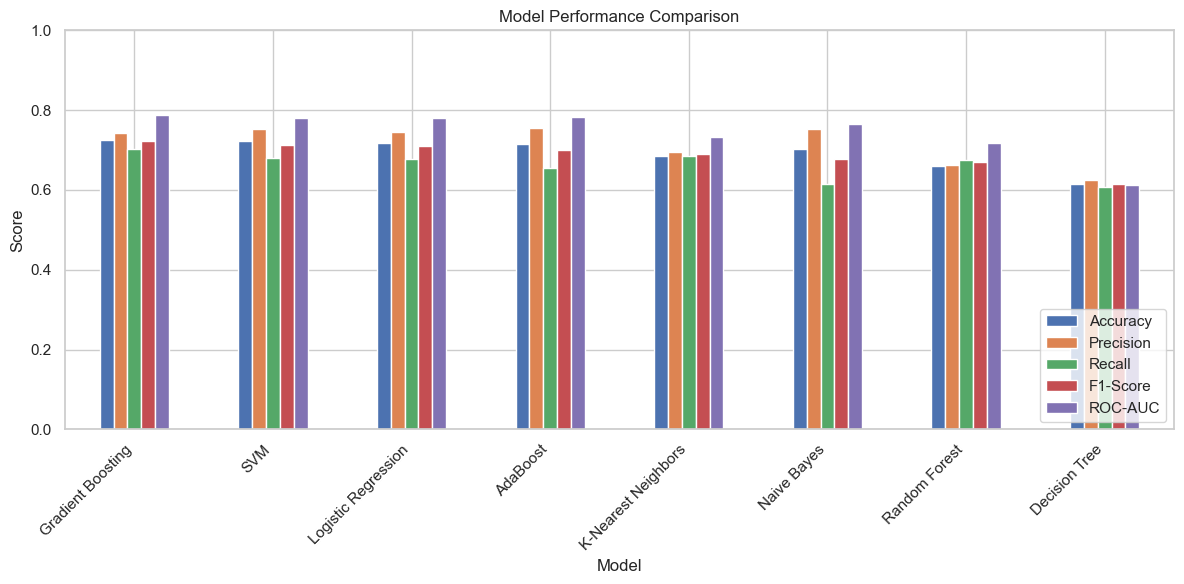

In [24]:
# Visual comparison of model scores
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics_to_plot]

plot_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Step 12: Detailed Evaluation of the Best Model**
- Inspect classification report, confusion matrix, and ROC curve for the top model by F1-Score.

In [25]:
# Select best model by F1-Score
best_model_name = results_df.iloc[0]['Model']
print('Best model based on F1-Score:', best_model_name)

best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_scaled)
y_prob_best = best_model.predict_proba(X_test_scaled)[:, 1]

print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=['No CVD', 'CVD']))

Best model based on F1-Score: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

      No CVD       0.71      0.75      0.73      6291
         CVD       0.74      0.70      0.72      6517

    accuracy                           0.73     12808
   macro avg       0.73      0.73      0.73     12808
weighted avg       0.73      0.73      0.73     12808



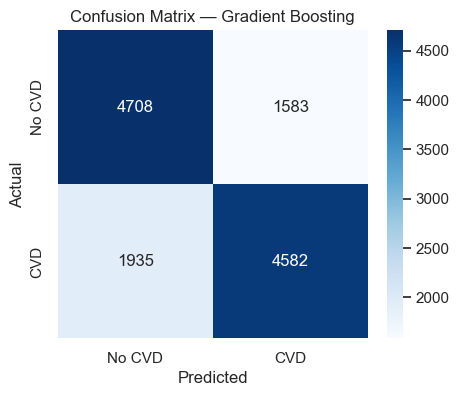

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['No CVD', 'CVD'],
    yticklabels=['No CVD', 'CVD']
)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

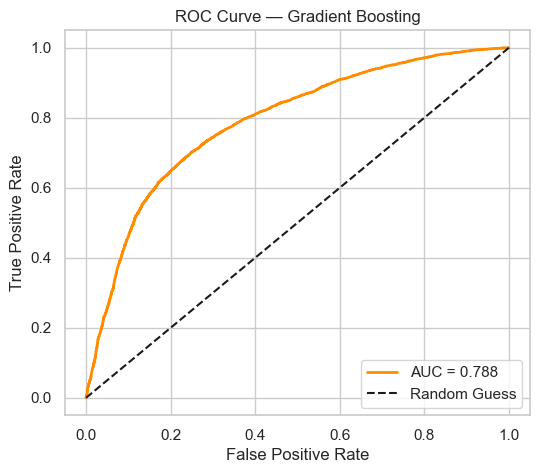

In [27]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)
auc_score = roc_auc_score(y_test, y_prob_best)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.3f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve — {best_model_name}')
plt.legend(loc='lower right')
plt.show()

**Step 13: Hyperparameter Tuning and Pipeline**

- Tune the best baseline model (Gradient Boosting) with GridSearchCV inside a scikit-learn Pipeline.
- In the first comparison, Gradient Boosting beat Random Forest on F1 and ROC-AUC

In [28]:
# Pipeline = scaling + Gradient Boosting
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

# Small grid: GB is slower than RF.
param_grid = {
    'classifier__n_estimators': [100, 150],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__max_depth': [2, 3]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit on UNSCALED training data because Pipeline already includes StandardScaler
grid.fit(X_train, y_train)

print('Best parameters:', grid.best_params_)
print('Best CV F1-score:', round(grid.best_score_, 4))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 2, 'classifier__n_estimators': 150}
Best CV F1-score: 0.7289


In [29]:
# Evaluate tuned Gradient Boosting pipeline on test set
best_pipe = grid.best_estimator_
y_pred_tuned = best_pipe.predict(X_test)
y_prob_tuned = best_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1-Score': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_tuned)
}

print('=== Tuned Gradient Boosting on Test Set ===')
for k, v in tuned_metrics.items():
    print(f'{k:10s}: {v:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_tuned, target_names=['No CVD', 'CVD']))

# Compare with the best UNTUNED model from Step 11
best_untuned_f1 = results_df.iloc[0]['F1-Score']
print('\nBest untuned model:', results_df.iloc[0]['Model'],
      '| F1 =', round(best_untuned_f1, 4))
print('Tuned GB pipeline F1 =', round(tuned_metrics['F1-Score'], 4))

# Prefer the tuned pipeline (includes scaler) when F1 is at least as good
if tuned_metrics['F1-Score'] + 1e-6 >= best_untuned_f1:
    final_model = best_pipe
    print('\nFinal saved model: tuned Gradient Boosting pipeline')
else:
    final_model = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', models[results_df.iloc[0]['Model']])
    ])
    final_model.fit(X_train, y_train)
    print('\nFinal saved model: untuned', results_df.iloc[0]['Model'], 'pipeline')

=== Tuned Gradient Boosting on Test Set ===
Accuracy  : 0.7239
Precision : 0.7421
Recall    : 0.7011
F1-Score  : 0.7210
ROC-AUC   : 0.7879

Classification Report:
              precision    recall  f1-score   support

      No CVD       0.71      0.75      0.73      6291
         CVD       0.74      0.70      0.72      6517

    accuracy                           0.72     12808
   macro avg       0.72      0.72      0.72     12808
weighted avg       0.72      0.72      0.72     12808


Best untuned model: Gradient Boosting | F1 = 0.7226
Tuned GB pipeline F1 = 0.721

Final saved model: untuned Gradient Boosting pipeline


**Step 14: Save the Trained Model**

- Save the final pipeline with joblib to reuse it later without retraining.

In [30]:
# Save the selected FINAL model (not automatically RF)
model_filename = 'cvd_prediction_model.joblib'
joblib.dump(final_model, model_filename)
print(f"Model saved as '{model_filename}'")

# Save feature column order for future inference
joblib.dump(list(X.columns), 'cvd_feature_columns.joblib')
print("Feature columns saved as 'cvd_feature_columns.joblib'")
print('Expected inference columns:', list(X.columns))

Model saved as 'cvd_prediction_model.joblib'
Feature columns saved as 'cvd_feature_columns.joblib'
Expected inference columns: ['age', 'gender', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']


**Step 15: Test with Unseen Data**
- Load the saved model and predict CVD risk for new sample patient profiles.

In [31]:
# Load saved artifacts
loaded_model = joblib.load('cvd_prediction_model.joblib')
feature_cols = joblib.load('cvd_feature_columns.joblib')

def prepare_patient(age, gender, height_cm, weight_kg, ap_hi, ap_lo,
                    cholesterol, gluc, smoke, alco, active):
    """Build one inference row using the SAME features as training."""
    row = {
        'age': age,
        'gender': gender,
        'ap_hi': ap_hi,
        'ap_lo': ap_lo,
        'cholesterol': cholesterol,
        'gluc': gluc,
        'smoke': smoke,
        'alco': alco,
        'active': active,
        'bmi': weight_kg / ((height_cm / 100) ** 2)
    }
    return {col: row[col] for col in feature_cols}

# Synthetic unseen patients (demo examples only)
unseen = pd.DataFrame([
    prepare_patient(55, 2, 170, 85, 150, 95, 3, 2, 1, 0, 0),  # higher-risk profile
    prepare_patient(35, 1, 165, 60, 115, 75, 1, 1, 0, 0, 1),  # lower-risk profile
])

print('Unseen patient data:')
print(unseen)

preds = loaded_model.predict(unseen)
probs = loaded_model.predict_proba(unseen)[:, 1]

for i, (pred, prob) in enumerate(zip(preds, probs), start=1):
    label = 'CVD Risk (Positive)' if pred == 1 else 'No CVD Risk (Negative)'
    print(f'Patient {i}: {label} | Probability of CVD = {prob:.3f}')

Unseen patient data:
   age  gender  ap_hi  ap_lo  cholesterol  gluc  smoke  alco  active  \
0   55       2    150     95            3     2      1     0       0   
1   35       1    115     75            1     1      0     0       1   

         bmi  
0  29.411765  
1  22.038567  
Patient 1: CVD Risk (Positive) | Probability of CVD = 0.890
Patient 2: No CVD Risk (Negative) | Probability of CVD = 0.084


**Interpretation of Results (Conclusion)**

- Gradient Boosting is the best performing model among the classifiers compared.
- Blood pressure, age, cholesterol, and BMI were the strongest predictive signals.
- Limitations: self-reported lifestyle fields may be noisy, dataset may not generalize to all populations, no ECG/family history, model is a screening aid, not a clinical diagnosis tool.